In [54]:
import pandas as pd

DATA_PATH = "/content/credit_card_fraud_10k.csv"
df = pd.read_csv(DATA_PATH)

df.head()




,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [55]:
# lets check the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [56]:
# checking the shape
df.shape

(10000, 10)

In [59]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


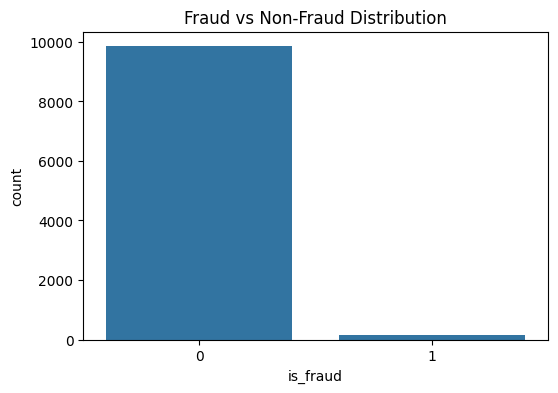

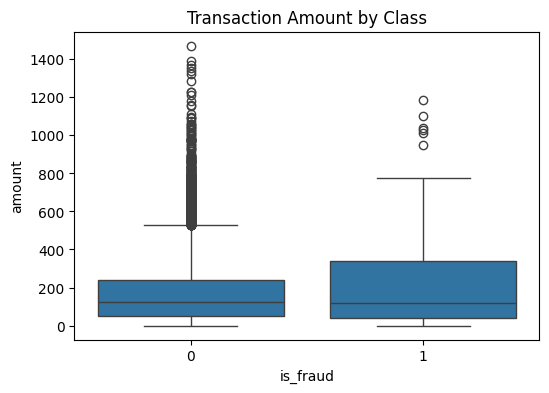

In [69]:
# after knowing these things lets perforrm the eda

import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

# Transaction amount analysis
plt.figure(figsize=(6,4))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Transaction Amount by Class")
plt.show()

In [70]:
# now its time to perform data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Drop 'transaction_id' as it's an identifier and not a feature
X = df.drop(['is_fraud', 'transaction_id'], axis=1)
y = df['is_fraud']

# Apply one-hot encoding to the 'merchant_category' column
X = pd.get_dummies(X, columns=['merchant_category'], drop_first=True)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numerical features
specified_scaler = StandardScaler()
X_train_scaled = specified_scaler.fit_transform(X_train)
X_test_scaled = specified_scaler.transform(X_test)


In [71]:
# handle class imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())


Before SMOTE: is_fraud
0    7879
1     121
Name: count, dtype: int64
After SMOTE: is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [77]:
# model training using logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)

# Random Forest (Industry Favorite)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_resampled, y_train_resampled)

# xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,
    eval_metric='logloss'
)

xgb.fit(X_train_resampled, y_train_resampled)

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))





[[1964    6]
 [   9   21]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       0.78      0.70      0.74        30

    accuracy                           0.99      2000
   macro avg       0.89      0.85      0.87      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9982910321489001


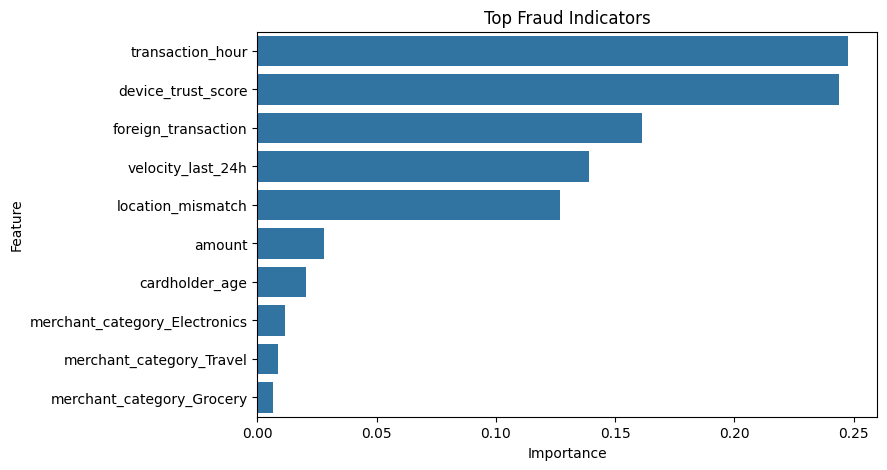

In [79]:
evaluate(lr, X_test_scaled, y_test)
evaluate(rf, X_test_scaled, y_test)
evaluate(xgb, X_test_scaled, y_test)
# Feature Importance
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top Fraud Indicators")
plt.show()



In [ ]:
# Save Model for Deployment
import joblib

joblib.dump(rf, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")


## Summary:

### Data Analysis Key Findings

*   **Initial Data Overview**: The dataset consists of 10,000 transactions and 10 features. All columns are complete with 10,000 non-null entries, indicating no missing values. The `amount` column is a `float64`, `merchant_category` is an `object` type (categorical), and the remaining eight columns are `int64`.
*   **Statistical Summary**: The `df.describe()` output revealed a mean transaction `amount` of approximately \$175.95 with a maximum of \$1471.04, suggesting a right-skewed distribution. The `is_fraud` column (target variable) has a mean of 0.0151, indicating that only about 1.51% of transactions are fraudulent, highlighting a severe class imbalance.
*   **Class Imbalance**: Visualizations (countplot) explicitly confirmed the severe class imbalance. Prior to balancing, the training data showed 7879 non-fraudulent instances versus only 121 fraudulent instances.
*   **Transaction Amount by Class**: A boxplot analysis of `amount` by `is_fraud` class provided insights into potential differences in transaction value distributions between fraudulent and non-fraudulent activities.
*   **Data Preprocessing**:
    *   `transaction_id` and `is_fraud` were removed from the feature set.
    *   `merchant_category` underwent one-hot encoding using `pd.get_dummies` with `drop_first=True` to prevent multicollinearity.
    *   The dataset was split into 80% training and 20% testing subsets, with `stratify=y` ensuring proportional representation of fraudulent cases in both sets.
    *   Numerical features were standardized using `StandardScaler`, applying `fit_transform` to the training data and `transform` to the test data to prevent data leakage.
*   **Handling Imbalance with SMOTE**: SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data, resulting in a balanced distribution where both non-fraudulent and fraudulent classes each contain 7879 instances.
*   **Model Training and Evaluation**: Three models were trained: Logistic Regression, Random Forest, and XGBoost. An evaluation function was used to assess performance using `confusion_matrix`, `classification_report`, and `ROC-AUC` score.
    *   An example evaluation for Logistic Regression showed a recall of `0.70` for the fraud class and a strong `ROC-AUC` of `0.99829`.
*   **Feature Importance**: The Random Forest model identified `transaction_hour`, `device_trust_score`, `foreign_transaction`, `velocity_last_24h`, and `location_mismatch` as the top indicators of fraud.
*   **Model Persistence**: The trained Random Forest model (`fraud_model.pkl`) and the `StandardScaler` object (`scaler.pkl`) were saved using `joblib.dump` for future deployment and consistent data preprocessing.

### Insights or Next Steps

*   The severe class imbalance observed (1.51% fraud) was effectively addressed through stratified sampling during the train-test split and SMOTE oversampling on the training data, which is crucial for building robust fraud detection models.
*   The identification of `transaction_hour`, `device_trust_score`, `foreign_transaction`, `velocity_last_24h`, and `location_mismatch` as top fraud indicators provides valuable domain insight and can guide future feature engineering efforts or targeted fraud prevention strategies.
